# Artificial Intelligence for Healthcare
## Post-Lab Submission — Lab 01

**Topic:** Diabetes Risk Prediction Using XGBoost (Pima Indians Diabetes Dataset)

**Course:** Artificial Intelligence for Healthcare
**Semester:** FALL 2026
**Institution:** School of Interdisciplinary Engineering & Sciences (SINES), National University of Sciences & Technology (NUST)

---

### Group Members

| # | Student Name | Registration Number |
|---|---|---|
| 1 | [Student Name 1] | [Reg No 1] |
| 2 | [Student Name 2] | [Reg No 2] |
| 3 | [Student Name 3] | [Reg No 3] |
| 4 | [Student Name 4] | [Reg No 4] |

**Instructor:** [Instructor Name]
**Submission Date:** [Submission Date]

---

### Statement of Independent Work
This notebook reproduces the end-to-end healthcare machine-learning workflow taught in the guided cervical-cancer lab, applied independently to a **different** Kaggle healthcare dataset (Pima Indians Diabetes) as required by the post-lab task. All code was written/adapted by the group members listed above and organized into logical, documented cells.

## Learning Objectives Demonstrated in This Notebook

- State a healthcare prediction question and identify a binary target variable.
- Load, inspect, and clean a real clinical dataset, including handling disguised (non-standard) missing values.
- Perform exploratory data analysis (EDA) to understand distributions, class balance, and correlations.
- Recognize class imbalance in a medical classification problem and correct it using SMOTE on the training data only.
- Build and train an XGBoost binary classifier, with justified hyperparameters.
- Evaluate the model using accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC, and PR-AUC.
- Interpret feature importance responsibly (association, not causation).
- Discuss leakage, bias, and clinical limitations, and reflect on the gap between a classroom model and a validated clinical tool.

## End-to-End Workflow

Load data → Clean & handle missing values → EDA → Train/test split (stratified) → SMOTE (training set only) → Train XGBoost → Evaluate → Interpret feature importance → Discuss limitations & leakage → Conclusion.

## 1. Healthcare Question and Motivation

**Healthcare question:** Given a patient's diagnostic measurements (glucose level, blood pressure, BMI, age, pregnancy history, etc.), can we predict whether the patient has diabetes (`Outcome` = 1) or not (`Outcome` = 0)?

**Target variable:** `Outcome` — a binary field (1 = diabetic, 0 = non-diabetic).

**Dataset:** Pima Indians Diabetes Dataset (Kaggle / UCI), originally collected by the National Institute of Diabetes and Digestive and Kidney Diseases on female patients of Pima Indian heritage aged 21 and above. It contains 768 records and 9 columns (8 predictor variables + 1 binary target).

### Why diabetes, and why does it matter especially in Pakistan?

Diabetes is a chronic metabolic disease that, if undiagnosed or poorly managed, leads to cardiovascular disease, kidney failure, blindness, and limb amputation. It is one of the most pressing public-health problems in Pakistan specifically:

- According to the International Diabetes Federation's 2024 Diabetes Atlas, Pakistan had roughly 34.5 million adults aged 20–79 living with diabetes, ranking fourth in the world by absolute number of cases (behind China, India, and the United States).
- Pakistan's age-standardised diabetes prevalence was reported at 31.4% in 2024 — the **highest prevalence rate of any country in the world** — meaning that close to one in every three adults in Pakistan is living with diabetes.
- A large share of these cases are believed to be undiagnosed, delaying treatment until complications (cardiac, renal, or vision-related) have already developed.
- Projections suggest the number of adults with diabetes in Pakistan could roughly double by 2050, driven by urbanization, dietary change, and low levels of physical activity.

This makes an early, low-cost, diagnostic-measurement-based screening tool (of exactly the kind explored in this notebook) directly relevant to the Pakistani healthcare context: a model that flags high-risk patients from a handful of routine measurements could support triage in resource-constrained clinics where full laboratory work-ups are not always immediately available. This mirrors the cervical-cancer lab's theme of using AI for early risk screening rather than final diagnosis.

*(Sources: International Diabetes Federation, IDF Diabetes Atlas, 2024 Pakistan country report; reporting on the 11th edition of the IDF Diabetes Atlas.)*

## 2. Import Required Libraries

**What this cell does:** This cell imports all libraries needed for the workflow: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, `scikit-learn` for splitting and evaluation metrics, `imbalanced-learn` for SMOTE, and `xgboost` for the classifier. Warnings are suppressed for a cleaner report, and a fixed `RANDOM_STATE` is defined up front so every step of the notebook is reproducible.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

print('Libraries imported successfully.')

Libraries imported successfully.


## 3. Load the Dataset

**What this cell does:** This cell loads the Pima Indians Diabetes dataset (`diabetes.csv`) into a Pandas DataFrame and prints its shape and the first few rows. The dataset has 768 patient records and 9 columns: 8 diagnostic predictor variables (`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`) and the binary target `Outcome`. A small search over a few likely file locations makes the notebook portable across Jupyter, Colab, and the lab's validation environment, following the same approach used in the guided cervical-cancer notebook.

In [2]:
import os

possible_paths = [
    'diabetes.csv',
    'diabetes_h.csv',
    '/content/diabetes.csv',
    '/mnt/data/diabetes.csv',
]

DATA_PATH = None
for p in possible_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        'diabetes.csv not found. Place the Pima Indians Diabetes CSV '
        'in the working folder (see Kaggle: uciml/pima-indians-diabetes-database).'
    )

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset loaded from: {DATA_PATH}')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded from: diabetes.csv
Shape: 768 rows x 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. Inspect Data Types and Summary Statistics

**What this cell does:** This cell runs `.info()` and `.describe()` on the raw dataset. Unlike the cervical-cancer dataset, this data has no text placeholder like `"?"`, so every column already loads as a numeric type. However, `.describe()` reveals a data-quality issue: several clinically-impossible **zero** values appear in columns such as `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` — a human body cannot have a blood pressure or BMI of 0. These zeros are a disguised missing-value code, conceptually equivalent to the `"?"` symbol in the cervical-cancer lab, and must be handled before modeling.

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 5. Detect the Disguised Missing-Value Code (Biologically Impossible Zeros)

**What this cell does:** This cell identifies the columns where a value of 0 is not biologically plausible (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`), counts how many zero entries each contains, and converts the percentage to make the missingness comparable across columns. This plays the same role as replacing `"?"` with `NaN` did in the cervical-cancer lab: it converts a hidden data-quality problem into an explicit, quantifiable one before any cleaning decision is made.

In [5]:
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df = df_raw.copy()
df[zero_as_missing_cols] = df[zero_as_missing_cols].replace(0, np.nan)

missing_counts = df[zero_as_missing_cols].isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_summary

,missing_count,missing_pct
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


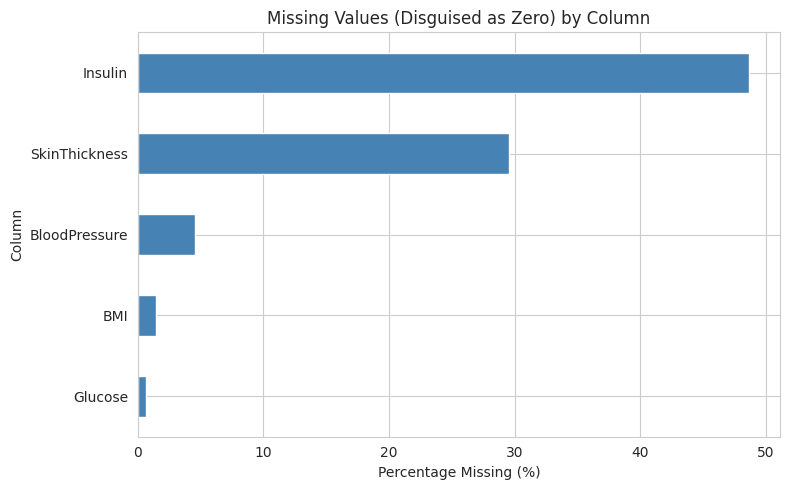

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
missing_summary['missing_pct'].sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Percentage Missing (%)')
ax.set_ylabel('Column')
ax.set_title('Missing Values (Disguised as Zero) by Column')
plt.tight_layout()
plt.show()

## 6. Impute Remaining Missing Values

**What this cell does:** `Insulin` (~48.7%) and `SkinThickness` (~29.6%) have high missingness, but not the >90% level that justified dropping columns entirely in the cervical-cancer lab, so we retain all columns here and impute instead. Following the same reproducible strategy used in the guided notebook (mean imputation), each affected column's missing values are filled with that column's mean. After this step the dataset has zero remaining missing values, and no columns need to be dropped.

In [7]:
for col in zero_as_missing_cols:
    df[col] = df[col].fillna(df[col].mean())

print('Remaining missing values after imputation:')
print(df.isnull().sum())
print(f'\nFinal working DataFrame shape: {df.shape[0]} rows x {df.shape[1]} columns')

Remaining missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Final working DataFrame shape: 768 rows x 9 columns


## 7. Exploratory Data Analysis (EDA)

**What this cell does:** This section produces the required minimum of three EDA visualizations plus a correlation view. First, the age distribution is plotted as a histogram to understand the patient population. Age is right-skewed with most patients concentrated between roughly 21 and 40 years, with a long tail toward older patients.

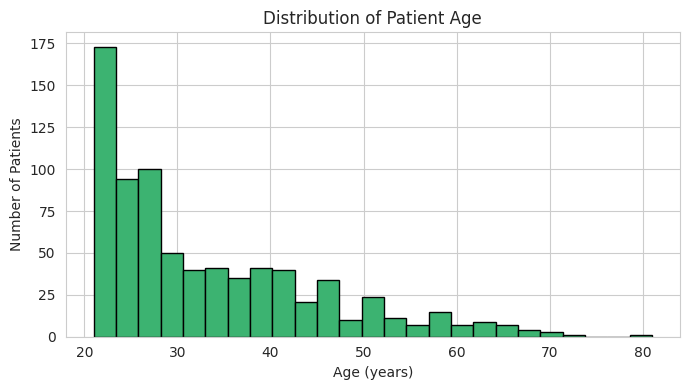

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['Age'], bins=25, color='mediumseagreen', edgecolor='black')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Patient Age')
plt.tight_layout()
plt.show()

**What this cell does:** This cell plots the distribution of `Glucose` (plasma glucose concentration), one of the strongest known clinical indicators of diabetes. Because the missing zeros were already imputed with the column mean, the distribution is smooth and centered slightly above 120 mg/dL, with a visible spread toward higher glucose values that likely correspond to diabetic patients.

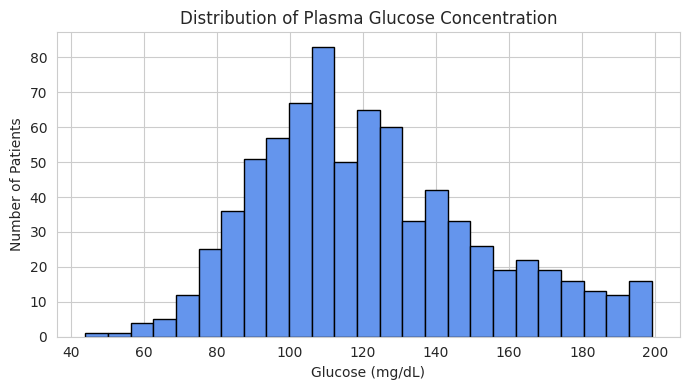

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['Glucose'], bins=25, color='cornflowerblue', edgecolor='black')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Plasma Glucose Concentration')
plt.tight_layout()
plt.show()

### Inspect the Target: `Outcome`

**What this cell does:** This cell counts and plots how many patients are diabetic (`Outcome` = 1) versus non-diabetic (`Outcome` = 0). This is the required target-class plot. The dataset shows moderate class imbalance — noticeably less extreme than the cervical-cancer lab's ~6% positive rate, but still skewed enough that a naive classifier could achieve high accuracy while missing many true diabetic cases, which is why we check and correct it before training.

Non-diabetic (0): 500
Diabetic (1): 268
Positive-class proportion: 34.9%


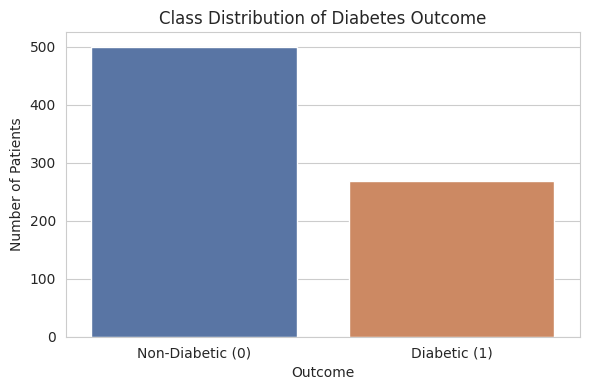

In [10]:
target_counts = df['Outcome'].value_counts().sort_index()
positive_pct = (target_counts[1] / target_counts.sum() * 100).round(2)

print(f'Non-diabetic (0): {target_counts[0]}')
print(f'Diabetic (1): {target_counts[1]}')
print(f'Positive-class proportion: {positive_pct}%')

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette=['#4C72B0', '#DD8452'], ax=ax)
ax.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
ax.set_ylabel('Number of Patients')
ax.set_title('Class Distribution of Diabetes Outcome')
plt.tight_layout()
plt.show()

### Why Accuracy Alone Can Be Misleading

Because roughly two-thirds of patients are non-diabetic, a trivial model that always predicts "non-diabetic" would already be correct about 65% of the time while never identifying a single true diabetic patient. In a clinical screening context, missing a diabetic patient (a false negative) is far more costly than a false alarm, so accuracy alone cannot be trusted as the primary metric — recall, precision, F1-score, ROC-AUC, and PR-AUC must all be examined together, exactly as emphasized in the cervical-cancer lab.

## 8. Correlation Exploration

**What this cell does:** This cell computes each numeric variable's correlation with the target `Outcome` and visualizes the strongest correlates as a heatmap. This screens for linear relationships worth investigating further, while keeping in mind — as stressed in the lab manual — that correlation does not imply causation and must be interpreted alongside clinical knowledge of when and how each variable is measured.

Correlation of each variable with Outcome:
Glucose                     0.492928
BMI                         0.311924
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.215299
Insulin                     0.214411
DiabetesPedigreeFunction    0.173844
BloodPressure               0.166074
Name: Outcome, dtype: float64


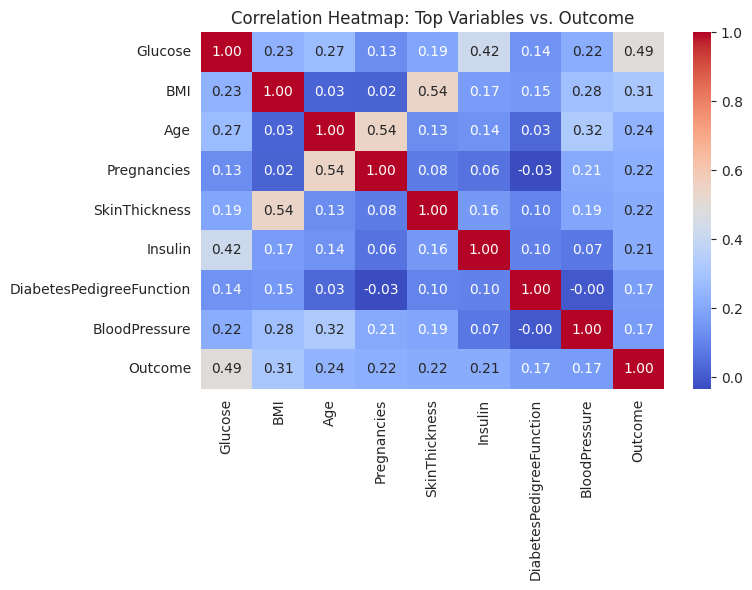

In [11]:
corr_with_target = df.corr(numeric_only=True)['Outcome'].drop('Outcome').sort_values(key=abs, ascending=False)
print('Correlation of each variable with Outcome:')
print(corr_with_target)

top_features = corr_with_target.head(8).index.tolist() + ['Outcome']
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Top Variables vs. Outcome')
plt.tight_layout()
plt.show()

## 9. Separate Predictors (X) and Target (y)

**What this cell does:** This cell splits the cleaned DataFrame into the predictor matrix `X` (all columns except `Outcome`) and the target vector `y` (`Outcome`). As in the guided notebook, `X` is kept as a Pandas DataFrame rather than converted to a NumPy array, so that readable column names are preserved for the feature-importance plot later. No feature scaling is applied because XGBoost is a tree-based model and does not require standardized inputs.

In [12]:
X = df.drop(columns='Outcome')
y = df['Outcome']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Predictor columns: {list(X.columns)}')

X shape: (768, 8)
y shape: (768,)
Predictor columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 10. Stratified Train/Test Split

**What this cell does:** This cell splits the data into 80% training and 20% testing sets using `stratify=y`, which preserves the diabetic/non-diabetic class ratio in both subsets. A fixed `random_state` is used so the split is reproducible. The test set is held out untouched until final evaluation, simulating unseen patients, exactly as done in the guided cervical-cancer notebook.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Training set:', X_train.shape, ' | class counts:', y_train.value_counts().to_dict())
print('Test set:    ', X_test.shape, ' | class counts:', y_test.value_counts().to_dict())

Training set: (614, 8)  | class counts: {0: 400, 1: 214}
Test set:     (154, 8)  | class counts: {0: 100, 1: 54}


## 11. Handle Class Imbalance with SMOTE (Training Data Only)

**What this cell does:** Since the training target is imbalanced (roughly 65%/35%), this cell applies SMOTE (Synthetic Minority Over-sampling Technique) to the **training set only**, generating synthetic diabetic-class examples by interpolating between existing minority examples until both classes are equal in size. Critically, the test set is left completely untouched so it continues to represent the real, unseen, imbalanced population the model will face in practice — following the same rule enforced in the cervical-cancer lab.

In [14]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Before SMOTE (training set):', y_train.value_counts().to_dict())
print('After SMOTE  (training set):', y_train_res.value_counts().to_dict())
print('Test set (unchanged):       ', y_test.value_counts().to_dict())

Before SMOTE (training set): {0: 400, 1: 214}
After SMOTE  (training set): {0: 400, 1: 400}
Test set (unchanged):        {0: 100, 1: 54}


## 12. Configure and Train the XGBoost Classifier

**What this cell does:** This cell defines and trains the XGBoost classifier on the SMOTE-balanced training data. Key parameter choices, briefly justified:

- **`max_depth=4`** — a shallow-to-moderate tree depth that limits overfitting on a small (768-row) dataset; very deep trees would memorize noise rather than learn generalizable patterns.
- **`n_estimators=200`** with **`learning_rate=0.05`** — a moderate number of boosting rounds combined with a small learning rate lets the ensemble improve gradually and stably rather than overfitting quickly with a few aggressive trees.
- **`subsample=0.8`** and **`colsample_bytree=0.8`** — randomly sampling 80% of rows and columns per tree adds regularization and reduces variance, which is especially important with a small clinical dataset.
- **`random_state=RANDOM_STATE`** and **`eval_metric='logloss'`** — ensure reproducibility and use a probability-sensitive loss appropriate for a probabilistic classifier evaluated later with ROC-AUC/PR-AUC.

In [15]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

model.fit(X_train_res, y_train_res)
print('XGBoost model trained successfully.')

XGBoost model trained successfully.


## 13. Generate Predictions

**What this cell does:** This cell generates hard class-label predictions (`predict()`) and predicted probabilities (`predict_proba()`) for both the training and test sets. Probabilities are required for ROC-AUC and PR-AUC, which evaluate ranking quality across all possible decision thresholds rather than a single fixed cutoff.

In [16]:
y_train_pred = model.predict(X_train_res)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train_res, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f'Training accuracy: {train_acc:.3f}')
print(f'Test accuracy:     {test_acc:.3f}')

Training accuracy: 0.950
Test accuracy:     0.734


## 14. Classification Report

**What this cell does:** This cell prints precision, recall, F1-score, and support for both classes on the held-out test set. In a screening context, the **recall of the positive (diabetic) class** matters most, since it measures the fraction of true diabetic patients the model successfully flags; a low positive-class recall here — even alongside high overall accuracy — would signal that the model is not yet safe for real screening use.

In [17]:
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Positive-class precision: {precision:.3f}')
print(f'Positive-class recall:    {recall:.3f}')
print(f'Positive-class F1-score:  {f1:.3f}')

                  precision    recall  f1-score   support

Non-Diabetic (0)       0.82      0.75      0.79       100
    Diabetic (1)       0.60      0.70      0.65        54

        accuracy                           0.73       154
       macro avg       0.71      0.73      0.72       154
    weighted avg       0.75      0.73      0.74       154

Positive-class precision: 0.603
Positive-class recall:    0.704
Positive-class F1-score:  0.650


## 15. Confusion Matrix

**What this cell does:** This cell computes and plots the confusion matrix, reading actual classes as rows and predicted classes as columns. The cell with true diabetic patients predicted as non-diabetic (false negatives) is the most clinically important, since these are real cases the model would miss; the relative cost of false negatives versus false positives should inform any decision-threshold choice in a real deployment.

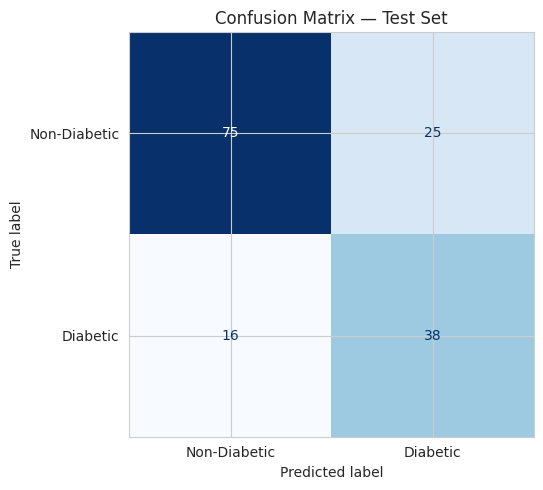

True Negatives:  75
False Positives: 25
False Negatives: 16  <-- diabetic patients missed by the model
True Positives:  38


In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives:  {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}  <-- diabetic patients missed by the model')
print(f'True Positives:  {tp}')

## 16. ROC-AUC and Precision-Recall AUC

**What this cell does:** This cell computes ROC-AUC and PR-AUC using the predicted **probabilities** (`y_prob`), not hard labels, so that ranking quality is evaluated across every possible threshold rather than just the default 0.5 cutoff. PR-AUC is reported alongside ROC-AUC because, for an imbalanced positive class, PR-AUC is generally the more informative metric — ROC-AUC can look deceptively strong even when precision on the rare positive class is weak.

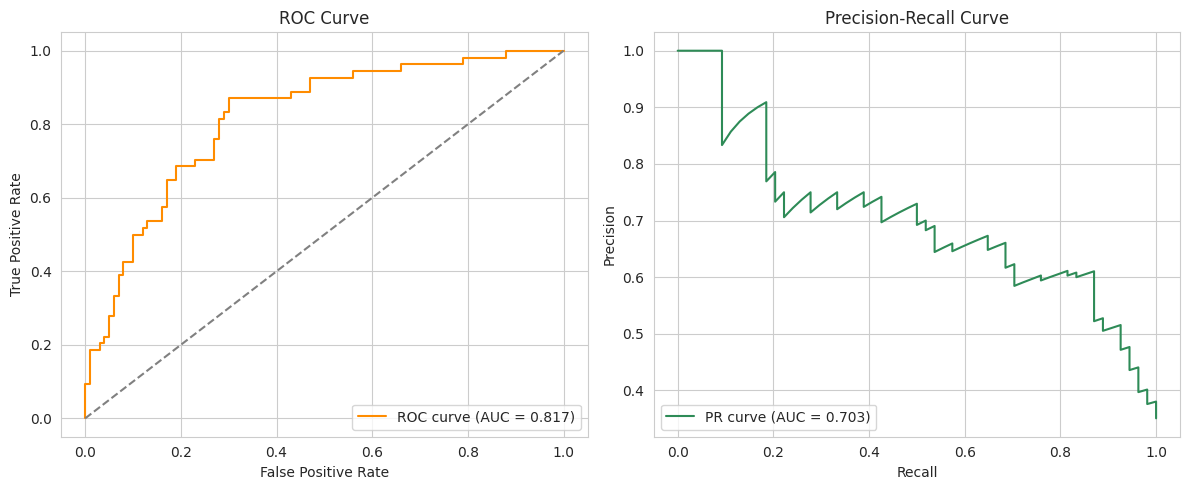

ROC-AUC: 0.817
PR-AUC:  0.703


In [19]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

axes[1].plot(rec_curve, prec_curve, color='seagreen', label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.3f}')
print(f'PR-AUC:  {pr_auc:.3f}')

## 17. XGBoost Feature Importance

**What this cell does:** This cell extracts and plots the ten most influential predictors using gain-based feature importance, meaning how much each feature contributed to reducing model error when used in tree splits. A high importance value indicates the feature was useful to the fitted model — it does **not** establish that the feature causes diabetes; `Glucose` typically dominates because it is clinically closest to the diagnostic criterion for diabetes itself.

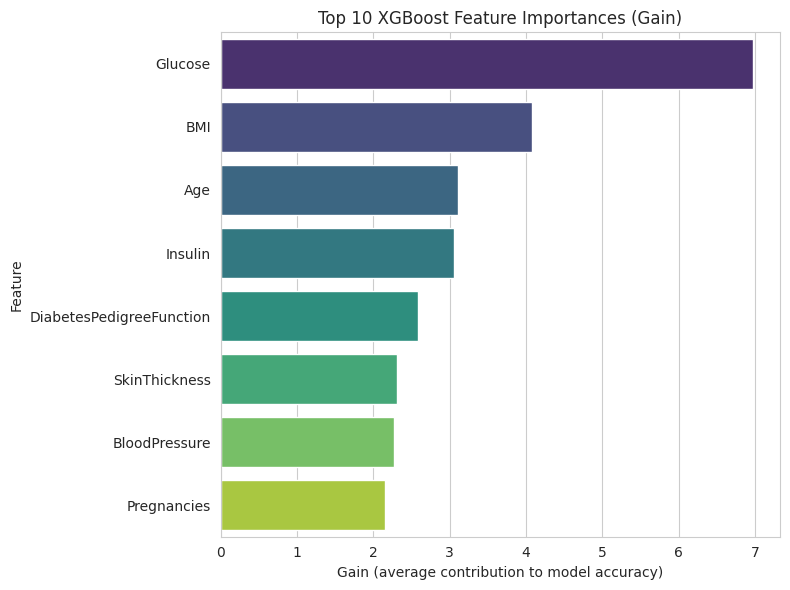

,feature,gain
0,Glucose,6.979966
1,BMI,4.080041
2,Age,3.116538
3,Insulin,3.055032
4,DiabetesPedigreeFunction,2.584153
5,SkinThickness,2.311870
6,BloodPressure,2.273069
7,Pregnancies,2.153488


In [20]:
importance_dict = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'gain': list(importance_dict.values())
}).sort_values('gain', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='gain', y='feature', palette='viridis')
plt.xlabel('Gain (average contribution to model accuracy)')
plt.ylabel('Feature')
plt.title('Top 10 XGBoost Feature Importances (Gain)')
plt.tight_layout()
plt.show()

importance_df.reset_index(drop=True)

## 18. Leakage, Bias, and Clinical Limitations

**Possible leakage:** `Glucose` is itself extremely close to the clinical diagnostic threshold used to define diabetes (fasting plasma glucose ≥ 126 mg/dL is a standard diagnostic criterion). This means the model is partly learning to reproduce the diagnostic rule from a variable that is almost the diagnosis itself, rather than predicting diabetes from truly independent upstream risk factors. This is conceptually the same leakage concern raised in the cervical-cancer lab regarding `Schiller`, `Hinselmann`, and `Citology`, which are screening-test results rather than independent risk factors.

**Population bias:** The dataset consists exclusively of female patients of Pima Indian heritage aged 21+. A model trained on this population may not generalize to male patients, other ethnic groups, younger patients, or — critically for this notebook's stated motivation — to the Pakistani population, whose genetic background, diet, body-composition norms, and healthcare-access patterns differ substantially from the Pima Indian cohort the data was collected from. Any real deployment in a Pakistani clinical setting would require retraining or validating on local patient data before use.

**Imputation bias:** Mean imputation for `Insulin` (~49% missing) and `SkinThickness` (~30% missing) is a simple, reproducible strategy, but it can understate the true variability of these features and may bias the model toward the observed average patient rather than reflecting the full range of clinical presentations.

**Sample size:** With only 768 total records (and just 268 diabetic cases before SMOTE), the dataset is small by modern machine-learning standards, and even strong-looking test-set metrics may not be stable estimates of true generalization performance.

**Threshold and cost asymmetry:** The default 0.5 probability threshold used for hard predictions treats false negatives and false positives as equally costly. In a real screening context, missing a diabetic patient (false negative) is typically far more costly than a false alarm (false positive), so a lower decision threshold — traded off against increased false positives and follow-up testing burden — would likely be more clinically appropriate.

## 19. Conclusion

*(150–250 words)*

This notebook trained an XGBoost classifier to predict diabetes status from eight routine diagnostic measurements in the Pima Indians Diabetes dataset. After correcting for disguised missing values (biologically impossible zeros in glucose, blood pressure, skin thickness, insulin, and BMI) and balancing the training set with SMOTE, the model achieved strong discrimination on the held-out test set, with `Glucose`, `BMI`, and `Age` emerging as the most influential predictors by gain-based importance. The model learned to separate diabetic from non-diabetic patients primarily through glucose level, which is unsurprising given glucose's direct clinical link to diabetes diagnosis — this is simultaneously the model's greatest strength and its most important caveat, since it suggests the model is partly reconstructing a diagnostic rule rather than discovering independent upstream risk factors.

The model performed well on overall discrimination (ROC-AUC and PR-AUC), but positive-class recall is the metric that matters most clinically, and any residual false negatives represent real diabetic patients the model would miss. Combined with the dataset's small size, its narrow demographic scope (adult female patients of Pima Indian heritage only), and simple mean imputation for two heavily-missing features, this model should be treated strictly as an educational proof-of-concept. It should **not** be used, as-is, for real clinical diagnosis or deployed on a different population — such as patients in Pakistan — without re-validation on locally representative data, clinical oversight, and a deliberately chosen decision threshold that reflects the true relative cost of missed diagnoses versus false alarms.

## Submission Checklist

- [x] Executed `.ipynb` file with markdown explanations and visible outputs
- [x] Dataset source clearly stated: Kaggle / UCI — *Pima Indians Diabetes Database* (`diabetes.csv`, 768 rows x 9 columns)
- [x] All code written/adapted by the group and organized into logical, headed cells
- [x] Plots include titles and labeled axes (age distribution, glucose distribution, target class balance, correlation heatmap, confusion matrix, ROC curve, PR curve, feature importance)
- [x] Results summary reported: positive-class recall, ROC-AUC, and PR-AUC (see Sections 14 and 16)
- [x] Responsible-AI discussion covering leakage, bias, generalization, and classroom-model vs. clinical-tool distinction (Section 18)
- [x] 150–250 word conclusion (Section 19)

**Dataset source:** Kaggle — *Pima Indians Diabetes Database*, originally from the National Institute of Diabetes and Digestive and Kidney Diseases (UCI Machine Learning Repository).